In [1]:
import os
from google.colab import drive

# Google Drive'a bağlanın
drive.mount('/content/drive')

Mounted at /content/drive


Found 98 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Validation Accuracy: 0.3333333432674408, Epochs: 36
Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Validation Accuracy: 0.3333333432674408, Epochs: 22
Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.1, Validation Accuracy: 0.3333333432674408, Epochs: 32
Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.001, Validation Accuracy: 0.3333333432674408, Epochs: 26
Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.01, Validation Accuracy: 0.0, Epochs: 24
Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.1, Validation Accuracy: 0.3333333432674408, Epochs: 28
Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.001, Validation Accuracy: 0.3333333432674408, Epochs: 22
Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.01, Validation Accuracy: 0.3333333432674408, Epochs: 30
Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.1, Validation Accuracy: 0.3333333432674408, Epochs: 24
Activation: tanh, Dropout

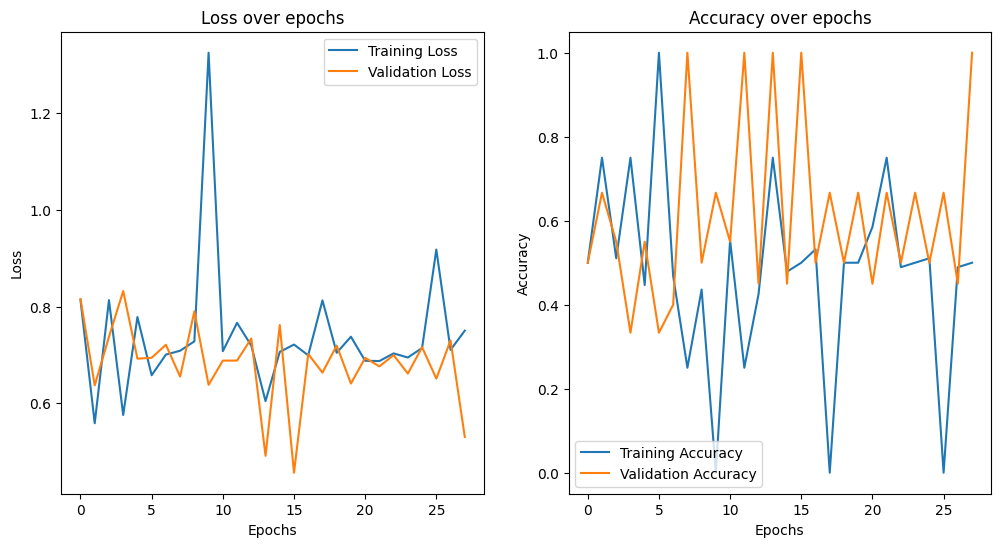

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step
Weighted Precision: 0.2722117202268431
Weighted Recall: 0.5217391304347826
Weighted F1 Score: 0.35776397515527947
Micro Precision: 0.5217391304347826
Micro Recall: 0.5217391304347826
Micro F1 Score: 0.5217391304347826
Macro Precision: 0.2608695652173913
Macro Recall: 0.5
Macro F1 Score: 0.34285714285714286
Precision (None): [0.         0.52173913]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.68571429]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# GPU bellek büyümesini etkinleştir
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Veri yolları
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/1) ürettiğimiz malicious kodlar/ss/'
img_height = 224
img_width = 224
batch_size = 4

# Veri üreteçleri
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hiperparametreler
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 50  # Test için daha az epoch ile başla

best_accuracy = 0
best_params = {}
all_results = []

results_file = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/4) makine eğitimi/training_results_efficientnetb0.json'

# Sonuç dosyasının var olup olmadığını kontrol et
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                # EfficientNetB0 modeli oluştur
                base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                for layer in base_model.layers:
                    layer.trainable = False

                x = GlobalAveragePooling2D()(base_model.output)
                x = Dense(512, activation=activation)(x)
                x = Dropout(dropout_rate)(x)
                output = Dense(1, activation='sigmoid')(x)

                model = Model(inputs=base_model.input, outputs=output)
                model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                              loss='binary_crossentropy',
                              metrics=['accuracy'])

                # Callback'leri tanımla
                early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
                model_checkpoint = ModelCheckpoint('best_model_efficientnetb0.keras', monitor='val_accuracy', save_best_only=True)

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping, model_checkpoint],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                num_epochs = len(history.history['loss'])  # Eğitim yapılan epoch sayısı
                result = {
                    'model': 'EfficientNetB0',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history,
                    'num_epochs': num_epochs
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}, Epochs: {num_epochs}")

            except Exception as e:
                print(f"Error with EfficientNetB0, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Eğer best_params boş değilse çizim ve tahmin işlemleri yap
if best_params:
    history = best_params['history']
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    # En iyi modeli yeniden oluştur ve eğitim yap
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=best_params['activation'])(x)
    x = Dropout(best_params['dropout_rate'])(x)
    best_output = Dense(1, activation='sigmoid')(x)

    best_model = Model(inputs=base_model.input, outputs=best_output)
    best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

    # En iyi modelin ağırlıklarını yükle
    best_model.load_weights('best_model_efficientnetb0.keras')

    predictions = best_model.predict(val_generator)
    y_true = val_generator.classes
    y_pred = (predictions > 0.5).astype(int)

    precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
    precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

    print("Weighted Precision:", precision_weighted)
    print("Weighted Recall:", recall_weighted)
    print("Weighted F1 Score:", f1_score_weighted)
    print("Micro Precision:", precision_micro)
    print("Micro Recall:", recall_micro)
    print("Micro F1 Score:", f1_score_micro)
    print("Macro Precision:", precision_macro)
    print("Macro Recall:", recall_macro)
    print("Macro F1 Score:", f1_score_macro)
    print("Precision (None):", precision_none)
    print("Recall (None):", recall_none)
    print("F1 Score (None):", f1_score_none)
else:
    print("No best parameters found.")


Found 98 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Weighted F1 Score: 0.35776397515527947, Epochs: 28


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.01, Weighted F1 Score: 0.35776397515527947, Epochs: 26


...

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Activation: sigmoid, Dropout Rate: 0.2, Learning Rate: 0.01, Weighted F1 Score: 0.35776397515527947, Epochs: 26


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Activation: sigmoid, Dropout Rate: 0.2, Learning Rate: 0.1, Weighted F1 Score: 0.35776397515527947, Epochs: 22

En iyi parametreler: {'model': 'EfficientNetB0', 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'f1_weighted': 0.35776397515527947, 'history': {'accuracy': [0.5319148898124695, 0.75, 0.457446813583374, 0.25, 0.4680851101875305, 0.75, 0.521276593208313, 0.75, 0.542553186416626, 0.25, 0.5319148898124695, 0.5, 0.5319148898124695, 0.5, 0.3617021143436432, 0.0, 0.4680851101875305, 0.5, 0.5106382966041565, 0.5, 0.5, 0.75, 0.542553186416626, 0.25, 0.521276593208313, 0.75, 0.478723406791687, 0.75], 'loss': [0.7359035015106201, 0.6631928086280823, 0.701352059841156, 0.7193443775177002, 0.6982720494270325, 0.6664146184921265, 0.6935738921165466, 0.6521872282028198, 0.6917767524719238, 0.7245500683784485, 0.6996055841445923, 0.7076364755630493, 0.6992138624191284, 0.6920596957206726, 0.6984128952026367, 0.7120020389556885, 0.69166

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


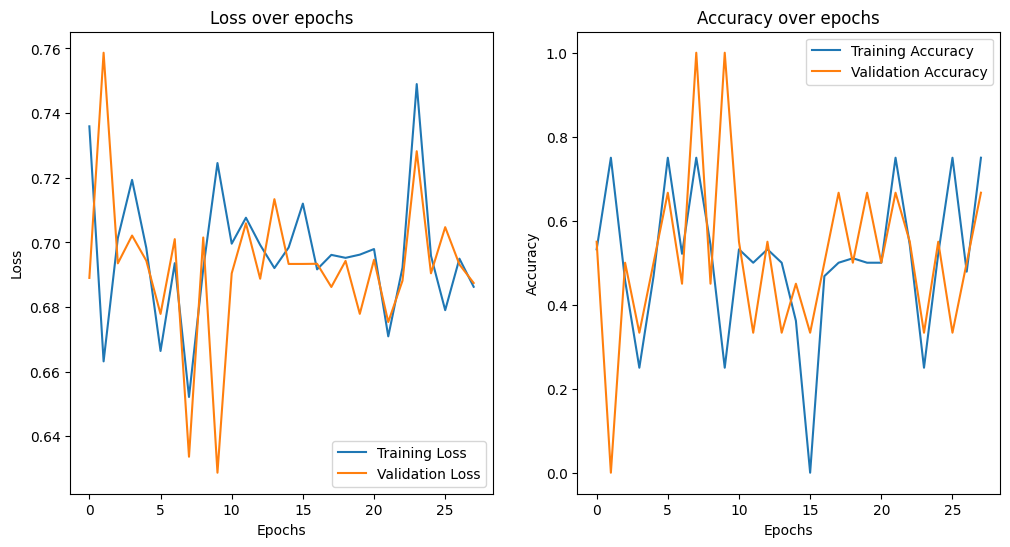

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Weighted Precision: 0.2722117202268431
Weighted Recall: 0.5217391304347826
Weighted F1 Score: 0.35776397515527947
Micro Precision: 0.5217391304347826
Micro Recall: 0.5217391304347826
Micro F1 Score: 0.5217391304347826
Macro Precision: 0.2608695652173913
Macro Recall: 0.5
Macro F1 Score: 0.34285714285714286
Precision (None): [0.         0.52173913]
Recall (None): [0. 1.]
F1 Score (None): [0.         0.68571429]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# GPU bellek büyümesini etkinleştir
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Veri yolları
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/1) ürettiğimiz malicious kodlar/ss/'
img_height = 224
img_width = 224
batch_size = 4

# Veri üreteçleri
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hiperparametreler
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [0.001, 0.01, 0.1]
epochs = 50  # Test için daha az epoch ile başla

best_f1_weighted = 0
best_params = {}
all_results = []

results_file = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/4) makine eğitimi/training_results_efficientnetb0.json'

# Sonuç dosyasının var olup olmadığını kontrol et
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                # EfficientNetB0 modeli oluştur
                base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                for layer in base_model.layers:
                    layer.trainable = False

                x = GlobalAveragePooling2D()(base_model.output)
                x = Dense(512, activation=activation)(x)
                x = Dropout(dropout_rate)(x)
                output = Dense(1, activation='sigmoid')(x)

                model = Model(inputs=base_model.input, outputs=output)
                model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                              loss='binary_crossentropy',
                              metrics=['accuracy'])

                # Callback'leri tanımla
                early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
                model_checkpoint = ModelCheckpoint('best_model_efficientnetb0.keras', monitor='val_accuracy', save_best_only=True)

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping, model_checkpoint],
                    verbose=0
                )

                # Tahminleri al ve F1 skorunu hesapla
                predictions = model.predict(val_generator)
                y_true = val_generator.classes
                y_pred = (predictions > 0.5).astype(int)

                precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

                num_epochs = len(history.history['loss'])  # Eğitim yapılan epoch sayısı
                result = {
                    'model': 'EfficientNetB0',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'f1_weighted': f1_weighted,
                    'history': history.history,
                    'num_epochs': num_epochs
                }
                all_results.append(result)

                if f1_weighted > best_f1_weighted:
                    best_f1_weighted = f1_weighted
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Weighted F1 Score: {f1_weighted}, Epochs: {num_epochs}")

            except Exception as e:
                print(f"Error with EfficientNetB0, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi ağırlıklı F1 skoru:", best_f1_weighted)

# Eğer best_params boş değilse çizim ve tahmin işlemleri yap
if best_params:
    history = best_params['history']
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    # En iyi modeli yeniden oluştur ve eğitim yap
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=best_params['activation'])(x)
    x = Dropout(best_params['dropout_rate'])(x)
    best_output = Dense(1, activation='sigmoid')(x)

    best_model = Model(inputs=base_model.input, outputs=best_output)
    best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

    # En iyi modelin ağırlıklarını yükle
    best_model.load_weights('best_model_efficientnetb0.keras')

    predictions = best_model.predict(val_generator)
    y_true = val_generator.classes
    y_pred = (predictions > 0.5).astype(int)

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
    precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

    print("Weighted Precision:", precision_weighted)
    print("Weighted Recall:", recall_weighted)
    print("Weighted F1 Score:", f1_weighted)
    print("Micro Precision:", precision_micro)
    print("Micro Recall:", recall_micro)
    print("Micro F1 Score:", f1_score_micro)
    print("Macro Precision:", precision_macro)
    print("Macro Recall:", recall_macro)
    print("Macro F1 Score:", f1_score_macro)
    print("Precision (None):", precision_none)
    print("Recall (None):", recall_none)
    print("F1 Score (None):", f1_score_none)
else:
    print("No best parameters found.")


Found 98 images belonging to 2 classes.
Found 23 images belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.001, Weighted F1 Score: 0.35776397515527947, Epochs: 28

En iyi parametreler: {'model': 'EfficientNetB0', 'activation': 'relu', 'dropout_rate': 0.0, 'learning_rate': 0.001, 'f1_weighted': 0.35776397515527947, 'history': {'accuracy': [0.521276593208313, 0.5, 0.42553192377090454, 0.5, 0.43617022037506104, 0.75, 0.5319148898124695, 0.75, 0.43617022037506104, 0.75, 0.542553186416626, 0.25, 0.44680851697921753, 0.75, 0.5319148898124695, 0.5, 0.521276593208313, 0.75, 0.5106382966041565, 1.0, 0.521276593208313, 0.25, 0.41489362716674805, 0.0, 0.521276593208313, 0.5, 0.521276593208313, 0.75], 'loss': [0.7019538283348083, 0.693171501159668, 0.718666136264801, 0.667731523513794, 0.7099864482879639, 0.6816115975379944, 0.7041007280349731, 0.6853973269462585, 0.7120145559310913, 0.6395218372344971, 0.697892963886261, 0.7160606384277344, 0.6995413899421692, 0.6600237488746643, 0.6921350359916687, 0.7109338045

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


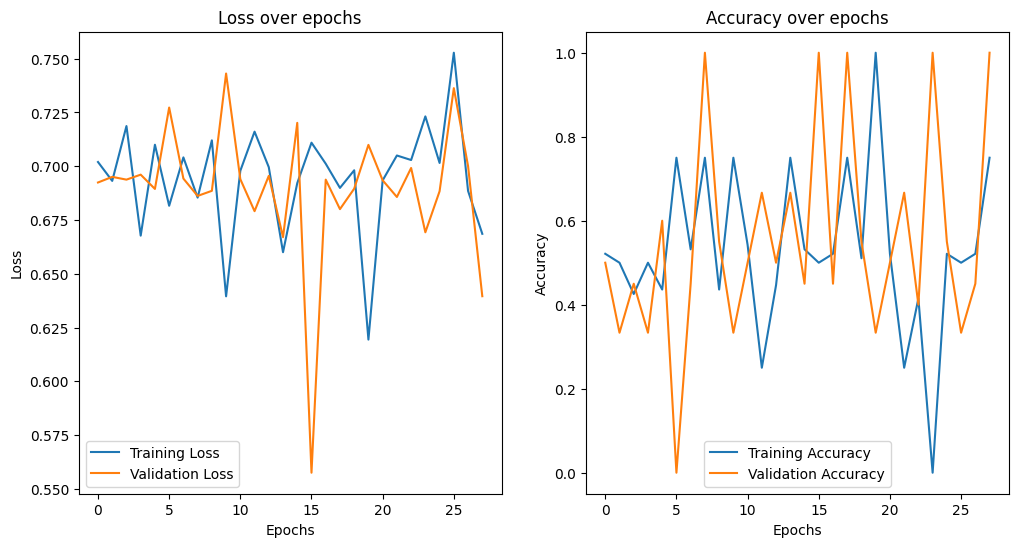

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Weighted Precision: 0.2287334593572779
Weighted Recall: 0.4782608695652174
Weighted F1 Score: 0.309462915601023
Micro Precision: 0.4782608695652174
Micro Recall: 0.4782608695652174
Micro F1 Score: 0.4782608695652174
Macro Precision: 0.2391304347826087
Macro Recall: 0.5
Macro F1 Score: 0.3235294117647059
Precision (None): [0.47826087 0.        ]
Recall (None): [1. 0.]
F1 Score (None): [0.64705882 0.        ]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import precision_recall_fscore_support
import json

# GPU bellek büyümesini etkinleştir
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Veri yolları
data_dir = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/1) ürettiğimiz malicious kodlar/ss/'
img_height = 224
img_width = 224
batch_size = 4

# Veri üreteçleri
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['0', '1']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['0', '1']
)

# Hiperparametreler
activations = ['relu']
dropout_rates = [0.0]
learning_rates = [0.001]
epochs = 50  # Test için daha az epoch ile başla

best_f1_weighted = 0
best_params = {}
all_results = []

results_file = '/content/drive/My Drive/Bitirme Çalışması/Malicious - harmless/4) makine eğitimi/training_results_efficientnetb0.json'

# Sonuç dosyasının var olup olmadığını kontrol et
if os.path.exists(results_file) and os.path.getsize(results_file) > 0:
    try:
        with open(results_file, 'r') as file:
            all_results = json.load(file)
    except json.JSONDecodeError:
        all_results = []
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                # EfficientNetB0 modeli oluştur
                base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
                for layer in base_model.layers:
                    layer.trainable = False

                x = GlobalAveragePooling2D()(base_model.output)
                x = Dense(512, activation=activation)(x)
                x = Dropout(dropout_rate)(x)
                output = Dense(1, activation='sigmoid')(x)

                model = Model(inputs=base_model.input, outputs=output)
                model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                              loss='binary_crossentropy',
                              metrics=['accuracy'])

                # Callback'leri tanımla
                early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
                model_checkpoint = ModelCheckpoint('best_model_efficientnetb0.keras', monitor='val_accuracy', save_best_only=True)

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping, model_checkpoint],
                    verbose=0
                )

                # Tahminleri al ve F1 skorunu hesapla
                predictions = model.predict(val_generator)
                y_true = val_generator.classes
                y_pred = (predictions > 0.5).astype(int)

                precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

                num_epochs = len(history.history['loss'])  # Eğitim yapılan epoch sayısı
                result = {
                    'model': 'EfficientNetB0',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'f1_weighted': f1_weighted,
                    'history': history.history,
                    'num_epochs': num_epochs
                }
                all_results.append(result)

                if f1_weighted > best_f1_weighted:
                    best_f1_weighted = f1_weighted
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Weighted F1 Score: {f1_weighted}, Epochs: {num_epochs}")

            except Exception as e:
                print(f"Error with EfficientNetB0, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi ağırlıklı F1 skoru:", best_f1_weighted)

# Eğer best_params boş değilse çizim ve tahmin işlemleri yap
if best_params:
    history = best_params['history']
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    # En iyi modeli yeniden oluştur ve eğitim yap
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=best_params['activation'])(x)
    x = Dropout(best_params['dropout_rate'])(x)
    best_output = Dense(1, activation='sigmoid')(x)

    best_model = Model(inputs=base_model.input, outputs=best_output)
    best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

    # En iyi modelin ağırlıklarını yükle
    best_model.load_weights('best_model_efficientnetb0.keras')

    predictions = best_model.predict(val_generator)
    y_true = val_generator.classes
    y_pred = (predictions > 0.5).astype(int)

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
    precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

    print("Weighted Precision:", precision_weighted)
    print("Weighted Recall:", recall_weighted)
    print("Weighted F1 Score:", f1_weighted)
    print("Micro Precision:", precision_micro)
    print("Micro Recall:", recall_micro)
    print("Micro F1 Score:", f1_score_micro)
    print("Macro Precision:", precision_macro)
    print("Macro Recall:", recall_macro)
    print("Macro F1 Score:", f1_score_macro)
    print("Precision (None):", precision_none)
    print("Recall (None):", recall_none)
    print("F1 Score (None):", f1_score_none)
else:
    print("No best parameters found.")
